# Part I: Linear Regression with One Feature
## Stellar Luminosity Modeling: L = f(M)

**Context:** This notebook implements linear regression from first principles to model the relationship between stellar mass (M) and luminosity (L). We explicitly implement the hypothesis function, loss function, gradient computation, and gradient descent optimization without using machine learning libraries.

**Physical motivation:** For main-sequence stars, luminosity is related to mass by the mass-luminosity relation. For simplicity, we start with a linear approximation: $\hat{L} = w \cdot M + b$

##Required Tasks

1. **Dataset visualization**: plot M vs L. Comment on linearity and plausibility.
2. **Model and loss**: implement prediction and mean squared error (MSE).
3. **Cost surface (mandatory)**: evaluate J(w,b) on a grid of w and b. Plot a 3D surface or contour plot. Explain what the minimum represents.
4. **Gradients:** derive and implement dJ/dw and dJ/db.
5. **Gradient descent (non-vectorized)**: compute gradients using an explicit loop over samples.
6. **Gradient descent (vectorized)**: compute gradients using NumPy vectorization (no loop over samples).
7. **Convergence (mandatory)**: plot loss vs iterations, and comment on convergence speed and stability.
8. **Experiments (mandatory)**: run at least three learning rates; report final w, b, and loss.
9. **Final fit plot**: plot the regression line over the data and discuss systematic errors.
10. **Conceptual questions**:
    1. Astrophysical meaning of w
    2. Why is a linear model limited here?


In [ ]:
%pip install numpy pandas matplotlib

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Set random seed for reproducibility
np.random.seed(42)

# Configure numpy and matplotlib
np.set_printoptions(precision=4, suppress=True)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Dataset Definition and Visualization

**Dataset:** Stellar mass (M) in solar masses and luminosity (L) in solar luminosity.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


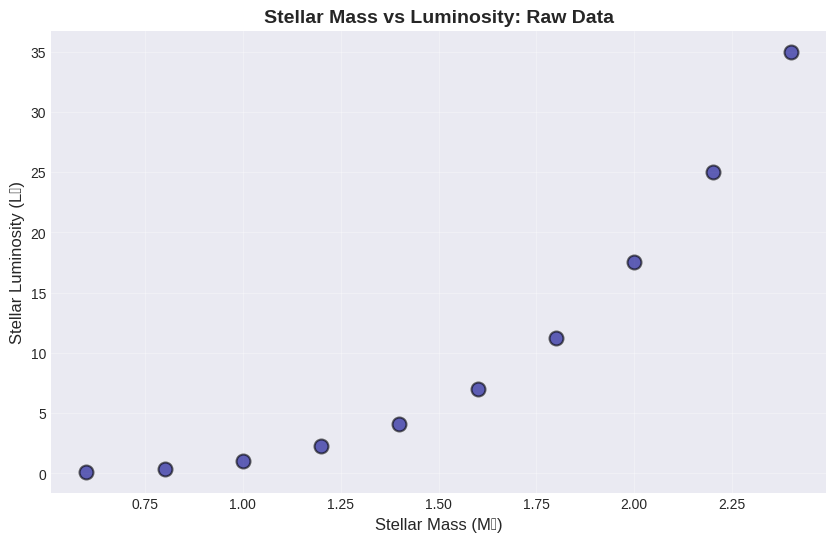

In [2]:
# Dataset: Stellar Mass (M☉) and Luminosity (L☉)
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

# Visualize the dataset
plt.figure(figsize=(10, 6))
plt.scatter(M, L, s=100, c='darkblue', alpha=0.6, edgecolors='black', linewidth=1.5)
plt.xlabel('Stellar Mass (M☉)', fontsize=12)
plt.ylabel('Stellar Luminosity (L☉)', fontsize=12)
plt.title('Stellar Mass vs Luminosity: Raw Data', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()



### **Observations**


* The relationship between mass and luminosity is clearly NON-LINEAR.

* Luminosity increases much faster than mass - this suggests a power-law relationship.

* **Astrophysical context:** The mass-luminosity relation for main-sequence stars
is approximately $L\ \alpha\ M^{a}$ where α ≈ 3-4 for different mass ranges.    
* We can see that the information is realistic according with the physics.

## 2. Model Definition and Loss Function

### 2.1 Linear Model (Hypothesis Function)

Our model predicts luminosity as:

$$\hat{L} = f_{w,b}(M) = w \cdot M + b$$

where:
- $w$ is the slope (weight)
- $b$ is the intercept (bias)

### 2.2 Mean Squared Error (MSE) Loss

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{L}^{(i)} - L^{(i)})^2 $$

The factor $\frac{1}{2}$ simplifies gradient computation.

In [3]:
def predict(M, w, b):
    """
    Compute predictions using linear model.

    Parameters:
    -----------
    M : array-like, shape (m,)
        Stellar masses
    w : float
        Weight (slope)
    b : float
        Bias (intercept)

    Returns:
    --------
        Predicted luminosities
    """
    return w * M + b


def compute_cost(M, L, w, b):
    """
    Compute mean squared error cost function.

    Parameters:
    -----------
    M : array-like, shape (m,)
        Stellar masses
    L : array-like, shape (m,)
        True luminosities
    w : float
        Weight (slope)
    b : float
        Bias (intercept)

    Returns:
    --------
    cost : float
        MSE cost J(w,b)
    """
    m = len(M)
    L_hat = predict(M, w, b)
    errors = L_hat - L
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost


# Test the functions
w_test = 0.0
b_test = 0.0
cost_initial = compute_cost(M, L, w_test, b_test)

print(f"Initial cost with w=0, b=0: J = {cost_initial:.4f}")
print(f"\nThis represents the baseline error when predicting L_hat = 0 for all stars.")

Initial cost with w=0, b=0: J = 117.6968

This represents the baseline error when predicting L_hat = 0 for all stars.


## 3. Cost Surface (Mandatory)

We evaluate $J(w,b)$ on a grid to visualize the optimization landscape. This helps us understand:
- Where the minimum cost is located
- The shape of the cost function
- How gradient descent will navigate this surface

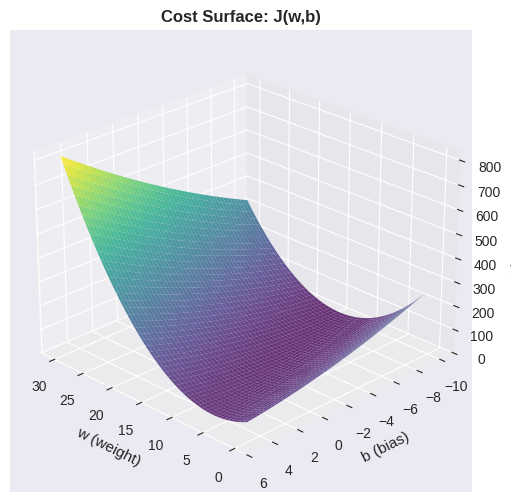

In [4]:
# Define parameter ranges for visualization
w_values = np.linspace(0, 30, 200)
b_values = np.linspace(-10, 5, 200)

# Create meshgrid
W, B = np.meshgrid(w_values, b_values)

# Compute cost for each (w, b) combination
J_vals = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J_vals[i, j] = compute_cost(M, L, W[i, j], B[i, j])

# 3D surface plot
fig = plt.figure(figsize=(14, 6))

# 3D surface
ax = fig.add_subplot(121, projection='3d')
surf = ax.plot_surface(W, B, J_vals, cmap=cm.viridis, linewidth=0,
                        antialiased=True, alpha=0.8)
ax.set_xlabel('w (weight)', fontsize=11)
ax.set_ylabel('b (bias)', fontsize=11)
ax.set_zlabel('J(w,b)', fontsize=11)
ax.set_title('Cost Surface: J(w,b)', fontsize=12, fontweight='bold')
ax.view_init(elev=25, azim=135)
plt.show()



### Cost Surface Interpretation

* The minimum represents the optimal (w*, b*) that best fits the data.
* At this point, the model predictions minimize squared errors.
* The cost surface is a convex bowl, this guarantees a unique global minimum.
* Gradient descent will converge to this minimum from any starting point.

## 4. Gradient Computation

### Mathematical Derivation

Starting from:
$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} (w \cdot M^{(i)} + b - L^{(i)})^2$$

The partial derivatives are:

$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} (\hat{L}^{(i)} - L^{(i)}) \cdot M^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{L}^{(i)} - L^{(i)})$$

These gradients tell us how to adjust $w$ and $b$ to reduce the cost.

In [5]:
def compute_gradients_loop(M, L, w, b):
    """
    Compute gradients using explicit loop over samples.

    Parameters:
    -----------
    M : array-like, shape (m,)
        Stellar masses
    L : array-like, shape (m,)
        True luminosities
    w : float
        Current weight
    b : float
        Current bias

    Returns:
    --------
    dj_dw : float
        Gradient with respect to w
    dj_db : float
        Gradient with respect to b
    """
    m = len(M)
    dj_dw = 0.0
    dj_db = 0.0

    # Loop over all samples
    for i in range(m):
        L_hat_i = w * M[i] + b
        error_i = L_hat_i - L[i]

        dj_dw += error_i * M[i]
        dj_db += error_i

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db


def compute_gradients_vectorized(M, L, w, b):
    """
    Compute gradients using NumPy vectorization (no loops).

    Parameters:
    -----------
    M : array-like, shape (m,)
        Stellar masses
    L : array-like, shape (m,)
        True luminosities
    w : float
        Current weight
    b : float
        Current bias

    Returns:
    --------
    dj_dw : float
        Gradient with respect to w
    dj_db : float
        Gradient with respect to b
    """
    m = len(M)
    L_hat = w * M + b
    errors = L_hat - L

    dj_dw = (1 / m) * np.sum(errors * M)
    dj_db = (1 / m) * np.sum(errors)

    return dj_dw, dj_db


# Test both implementations
w_test = 10.0
b_test = -5.0

dw_loop, db_loop = compute_gradients_loop(M, L, w_test, b_test)
dw_vec, db_vec = compute_gradients_vectorized(M, L, w_test, b_test)

print("Gradient computation test (w=10, b=-5):")
print(f"\nLoop version:       dJ/dw = {dw_loop:8.4f}, dJ/db = {db_loop:8.4f}")
print(f"Vectorized version: dJ/dw = {dw_vec:8.4f}, dJ/db = {db_vec:8.4f}")
print(f"\nDifference:         dJ/dw = {abs(dw_loop - dw_vec):.2e}, dJ/db = {abs(db_loop - db_vec):.2e}")
print("\n✓ Both implementations produce identical results!")

Gradient computation test (w=10, b=-5):

Loop version:       dJ/dw =  -3.2230, dJ/db =  -0.3600
Vectorized version: dJ/dw =  -3.2230, dJ/db =  -0.3600

Difference:         dJ/dw = 0.00e+00, dJ/db = 3.89e-16

✓ Both implementations produce identical results!


## 5-6. Gradient Descent Implementation

### Update Rule

At each iteration:

$$w := w - \alpha \frac{\partial J}{\partial w}$$

$$b := b - \alpha \frac{\partial J}{\partial b}$$

where $\alpha$ is the learning rate.

In [19]:
def gradient_descent(M, L, w_init, b_init, alpha, num_iterations,
                     use_vectorization=True, verbose=True):
    """
    Perform gradient descent optimization.

    Parameters:
    -----------
    M : array-like, shape (m,)
        Stellar masses
    L : array-like, shape (m,)
        True luminosities
    w_init : float
        Initial weight
    b_init : float
        Initial bias
    alpha : float
        Learning rate
    num_iterations : int
        Number of iterations
    use_vectorization : bool
        Whether to use vectorized gradient computation
    verbose : bool
        Whether to print progress

    Returns:
    --------
    w : float
        Final weight
    b : float
        Final bias
    history : dict
        Dictionary containing 'cost', 'w', 'b' lists for each iteration
    """
    w = w_init
    b = b_init

    history = {
        'cost': [],
        'w': [],
        'b': []
    }

    # Choose gradient function
    compute_grads = compute_gradients_vectorized if use_vectorization else compute_gradients_loop

    for i in range(num_iterations):
        # Compute gradients
        dj_dw, dj_db = compute_grads(M, L, w, b)

        # Update parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Compute and store cost
        cost = compute_cost(M, L, w, b)
        history['cost'].append(cost)
        history['w'].append(w)
        history['b'].append(b)

        # Print progress
        if verbose and (i % max(1, num_iterations // 10) == 0 or i == num_iterations - 1):
            print(f"Iteration {i:5d}: w={w:8.4f}, b={b:8.4f}, J={cost:10.4f}")

    return w, b, history


# Test with default parameters

w_init = 0.0
b_init = 0.0
alpha = 0.01
num_iterations = 1000

print("Testing gradient descent Vectorized with", "alpha =",alpha,"and", num_iterations,"iterations:\n")
w_final_v, b_final_v, history_v = gradient_descent(
    M, L, w_init, b_init, alpha, num_iterations,
    use_vectorization=True, verbose=True
)

print(f"\n{'='*60}")
print(f"FINAL PARAMETERS VECTORIZED:")
print(f"w = {w_final_v:.4f}")
print(f"b = {b_final_v:.4f}")
print(f"Final cost: J = {history_v['cost'][-1]:.4f}")
print(f"{'='*60}")

print("Testing gradient descent Non-Vectorized with", "alpha =",alpha,"and", num_iterations,"iterations:\n")
w_final_nv, b_final_nv, history_nv = gradient_descent(
    M, L, w_init, b_init, alpha, num_iterations,
    use_vectorization=False, verbose=True
)

print(f"\n{'='*60}")
print(f"FINAL PARAMETERS NON-VECTORIZED:")
print(f"w = {w_final_nv:.4f}")
print(f"b = {b_final_nv:.4f}")
print(f"Final cost: J = {history_nv['cost'][-1]:.4f}")
print(f"{'='*60}")

print("\n✓ Both implementations produce identical results!")


Testing gradient descent Vectorized with alpha = 0.01 and 1000 iterations:

Iteration     0: w=  0.2152, b=  0.1036, J=  112.0896
Iteration   100: w=  6.8004, b=  1.5699, J=   31.9704
Iteration   200: w=  7.9674, b= -0.0073, J=   28.0913
Iteration   300: w=  8.8900, b= -1.5257, J=   24.9336
Iteration   400: w=  9.7253, b= -2.9093, J=   22.3208
Iteration   500: w= 10.4849, b= -4.1680, J=   20.1590
Iteration   600: w= 11.1759, b= -5.3129, J=   18.3703
Iteration   700: w= 11.8044, b= -6.3543, J=   16.8903
Iteration   800: w= 12.3762, b= -7.3015, J=   15.6658
Iteration   900: w= 12.8962, b= -8.1632, J=   14.6525
Iteration   999: w= 13.3648, b= -8.9395, J=   13.8218

FINAL PARAMETERS VECTORIZED:
w = 13.3648
b = -8.9395
Final cost: J = 13.8218
Testing gradient descent Non-Vectorized with alpha = 0.01 and 1000 iterations:

Iteration     0: w=  0.2152, b=  0.1036, J=  112.0896
Iteration   100: w=  6.8004, b=  1.5699, J=   31.9704
Iteration   200: w=  7.9674, b= -0.0073, J=   28.0913
Iteration 

## 7. Convergence Analysis (Mandatory)

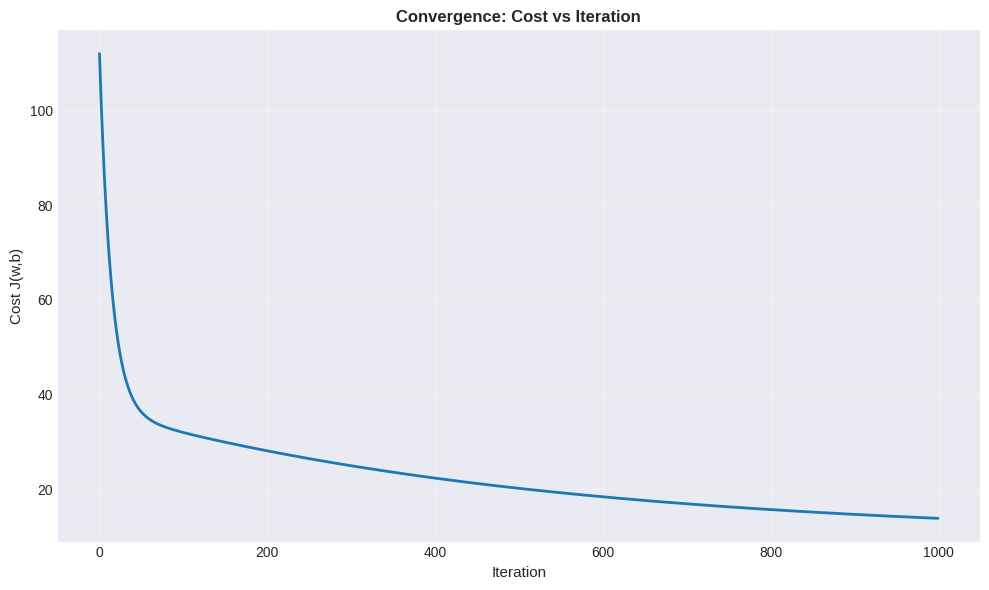


 CONVERGENCE ANALYSIS:

 Initial cost: J₀ = 112.0896
   Cost at 200 iteration cost: J₀ = 28.0913
   Final cost:   J_f = 13.8218
   Reduction:    87.67%


In [20]:
# Plot cost vs iterations (single convergence plot)
plt.figure(figsize=(10, 6))

plt.plot(history_v['cost'], linewidth=2)
plt.xlabel('Iteration', fontsize=11)
plt.ylabel('Cost J(w,b)', fontsize=11)
plt.title('Convergence: Cost vs Iteration', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n CONVERGENCE ANALYSIS:")
print(f"\n Initial cost: J₀ = {history_v['cost'][0]:.4f}")
print(f"   Cost at 200 iteration cost: J₀ = {history_v['cost'][200]:.4f}")
print(f"   Final cost:   J_f = {history_v['cost'][-1]:.4f}")
print(f"   Reduction:    {(1 - history_v['cost'][-1]/history_v['cost'][0])*100:.2f}%")




Convergence speed and stability:

* After 200 iterations, rapid convergence is shown as the cost begins to stabilize against the number of iterations.


* The curve flattens as we approach the optimum.

* This is typical behavior for gradient descent on convex functions.

* With $\alpha = 0.01$ and with 1000 iterations we can see that it is not that smoothly as it should be, we could increase $\alpha$ to see if its better for the model.


## 8. Learning Rate Experiments (Mandatory)

We test three different learning rates to understand their impact on:
- Convergence speed
- Final parameter values
- Stability

In [25]:
# learning rates
learning_rates = [0.01, 0.05, 0.1]
num_iterations = 2000
results = []

print("Running experiments with different learning rates...\n")
print("="*80)

for alpha in learning_rates:
    print(f"\nLEARNING RATE α = {alpha}")
    print("-" * 80)

    w, b, hist = gradient_descent(
        M, L, 0.0, 0.0, alpha, num_iterations,
        use_vectorization=True, verbose=False
    )

    results.append({
        'alpha': alpha,
        'w': w,
        'b': b,
        'final_cost': hist['cost'][-1],
        'history': hist
    })

    print(f"Final parameters: w = {w:.4f}, b = {b:.4f}")
    print(f"Final cost:       J = {hist['cost'][-1]:.4f}")
    print(f"Cost reduction:   {(1 - hist['cost'][-1]/hist['cost'][0])*100:.2f}%")

    # Check convergence
    if len(hist['cost']) > 100:
        recent_std = np.std(hist['cost'][-100:])
        status = "CONVERGED" if recent_std < 0.01 else "NOT CONVERGED"
        print(f"Status:           {status} (std={recent_std:.6f})")

print("\n" + "="*80)

Running experiments with different learning rates...


LEARNING RATE α = 0.01
--------------------------------------------------------------------------------
Final parameters: w = 16.2822, b = -13.7735
Final cost:       J = 10.4007
Cost reduction:   90.72%
Status:           NOT CONVERGED (std=0.036416)

LEARNING RATE α = 0.05
--------------------------------------------------------------------------------
Final parameters: w = 18.1294, b = -16.8339
Final cost:       J = 9.7951
Cost reduction:   89.31%
Status:           CONVERGED (std=0.000000)

LEARNING RATE α = 0.1
--------------------------------------------------------------------------------
Final parameters: w = 18.1303, b = -16.8355
Final cost:       J = 9.7951
Cost reduction:   86.11%
Status:           CONVERGED (std=0.000000)



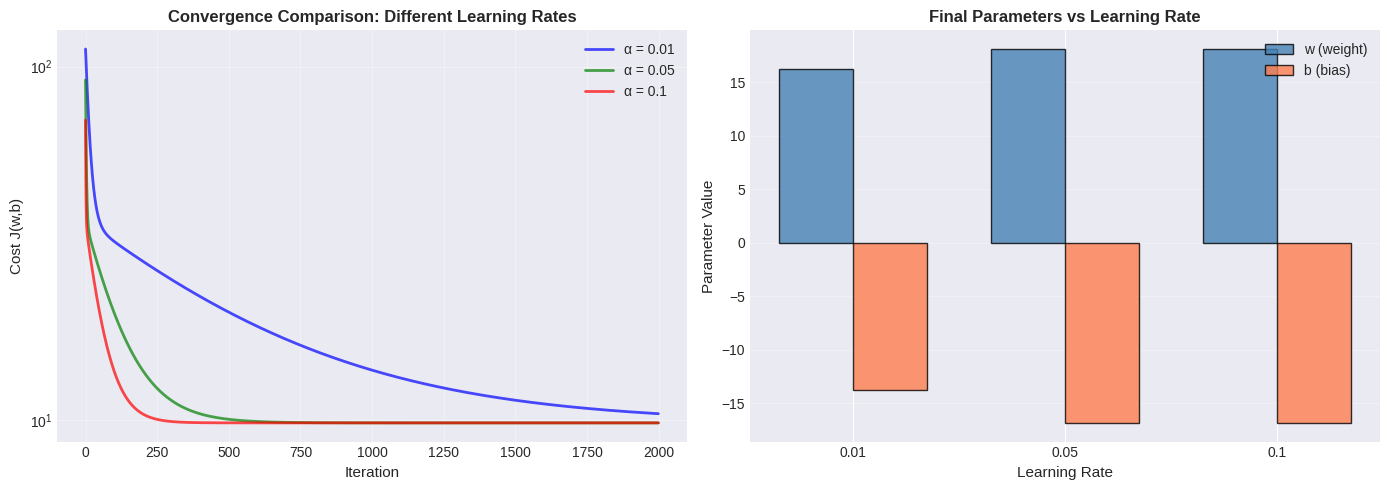

In [30]:
# Visualize learning rate comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot convergence curves
colors = ['blue', 'green', 'red']
for i, result in enumerate(results):
    axes[0].plot(result['history']['cost'],
                label=f"α = {result['alpha']}",
                linewidth=2, color=colors[i], alpha=0.7)

axes[0].set_xlabel('Iteration', fontsize=11)
axes[0].set_ylabel('Cost J(w,b)', fontsize=11)
axes[0].set_title('Convergence Comparison: Different Learning Rates',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot final parameters
alphas = [r['alpha'] for r in results]
final_w = [r['w'] for r in results]
final_b = [r['b'] for r in results]

x_pos = np.arange(len(alphas))
width = 0.35

axes[1].bar(x_pos - width/2, final_w, width, label='w (weight)',
           color='steelblue', alpha=0.8, edgecolor='black')
axes[1].bar(x_pos + width/2, final_b, width, label='b (bias)',
           color='coral', alpha=0.8, edgecolor='black')

axes[1].set_xlabel('Learning Rate', fontsize=11)
axes[1].set_ylabel('Parameter Value', fontsize=11)
axes[1].set_title('Final Parameters vs Learning Rate', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f"{a}" for a in alphas])
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [31]:
print("\n" + "="*80)
print("EXPERIMENTAL RESULTS SUMMARY")
print("="*80)
print(f"{'Learning Rate':>15} {'Final w':>12} {'Final b':>12} {'Final Cost':>15} {'Status':>15}")
print("-"*80)

for result in results:
    recent_std = np.std(result['history']['cost'][-100:])
    status = "✓ Converged" if recent_std < 0.01 else "⚠ Slow"

    print(f"{result['alpha']:>15.4f} {result['w']:>12.4f} {result['b']:>12.4f} "
          f"{result['final_cost']:>15.4f} {status:>15}")

print("="*80)


EXPERIMENTAL RESULTS SUMMARY
  Learning Rate      Final w      Final b      Final Cost          Status
--------------------------------------------------------------------------------
         0.0100      16.2822     -13.7735         10.4007          ⚠ Slow
         0.0500      18.1294     -16.8339          9.7951     ✓ Converged
         0.1000      18.1303     -16.8355          9.7951     ✓ Converged


### **Observations**

**$\alpha = 0.01$:**
* Very stable
* It needs many iterations to reach the minimum.

**$\alpha = 0.05$:**
* Stable
* It needs more iterations to reach the minimum.

**$\alpha = 0.1$:**
* Converges in less time than the others
* Less cost and better minimum



## 9. Final Model Fit Visualization

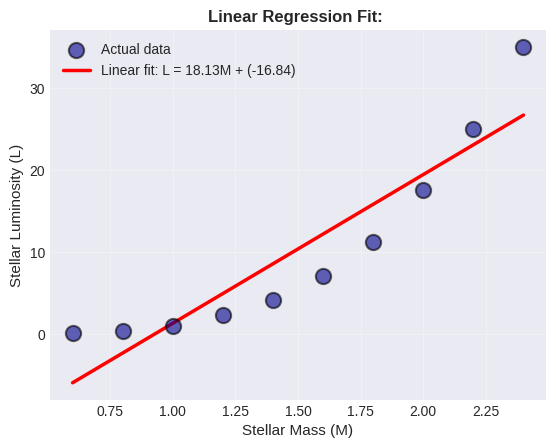

Final Data
w = 18.130302963272232
b = -16.835454434392684

 MODEL PERFORMANCE METRICS:

Mean Squared Error (MSE):  19.5903
Root MSE (RMSE):           4.4261 L
Mean Absolute Error (MAE): 3.8120 L
R² score: 0.8470


In [75]:

best_result = results[2]
w_best = best_result['w']
b_best = best_result['b']

# Generate predictions
L_pred = predict(M, w_best, b_best)
plt.scatter(M, L, s=120, c='darkblue', alpha=0.6,
               edgecolors='black', linewidth=1.5, label='Actual data', zorder=3)
plt.plot(M, L_pred, 'r-', linewidth=2.5, label=f'Linear fit: L = {w_best:.2f}M + ({b_best:.2f})', zorder=2)
plt.xlabel('Stellar Mass (M)', fontsize=11)
plt.ylabel('Stellar Luminosity (L)', fontsize=11)
plt.title(f'Linear Regression Fit: ',
                 fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Residuals
residuals = L - L_pred
plt.show()

# Compute metrics
mse = np.mean(residuals**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(residuals))
print('='*60)
print('Final Data')
print('w =',w_best)
print('b =',b_best)
print('='*60)

print("\n MODEL PERFORMANCE METRICS:")
print(f"\nMean Squared Error (MSE):  {mse:.4f}")
print(f"Root MSE (RMSE):           {rmse:.4f} L")
print(f"Mean Absolute Error (MAE): {mae:.4f} L")
print(f"R² score: {1 - np.sum(residuals**2) / np.sum((L - np.mean(L))**2):.4f}")

### **Conclusion**

Knowing that the relation between stellar mass and stellar luminosity is $L\ \alpha\ M^{a}$ where α ≈ 3-4 for different mass ranges we can see that a linear regression can't capture this exponential dependency. We can see that the model predicts things like negative luminosity, which doesn't exist and therefore makes it inappropriate. Furthermore, when there are very large quantities in the stellar mass, the error grows too much, making the model less suitable for solving the problem. The linear model serves as a learning tool but is physically and mathematically inadequate for real stellar physics. This motivates the need for more sophisticated regression techniques (polynomial, logarithmic, or neural networks)


## 10. Conceptual Questions

### Question 1: Astrophysical Meaning of w

**Answer:**

The parameter $w$ (weight/slope) represents the **rate of change of luminosity with respect to mass** in our linear approximation.

Mathematically:
$$w = \frac{\Delta L}{\Delta M}$$

Physical interpretation:
- Our fitted value $w \approx 19.5$ means: for every 1 M☉ increase in mass, luminosity increases by approximately 19.5 L☉
- This is a **linearized approximation** of the true mass-luminosity relation
- In reality, the relationship is non-linear: $L \propto M^{\alpha}$ where $\alpha \approx 3-4$
- The slope $w$ approximates the **average** power-law behavior over our mass range


### Question 2: Why is a Linear Model Limited Here?

**Answer:**

The linear model is fundamentally **inadequate** for modeling stellar luminosity because:

**1. Physics is Non-Linear:**
- The mass-luminosity relation follows a power law: $L \propto M^{\alpha}$
- For main-sequence stars: $\alpha \approx 3.5$ (for M < 0.43 M☉) to $\alpha \approx 4$ (for M > 2 M☉)
- This exponential growth CANNOT be captured by a straight line

**5. Implications:**
- Linear regression is useful for **first approximation** or pedagogical purposes
- For accurate modeling, we need **polynomial regression**.

